In [52]:
import pandas as pd
import numpy as np
import pyranges as pe
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

from data import create_saluki_dataloaders
from model import SalukiModel

In [35]:
checkpoint_path = '/s/project/ml4rg_students/2026/project03/project-half-life/outputs/out_setup/19470366_06-16-13-06/model_best_19470366_06-16-13-06.pt'

In [36]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [37]:
model = SalukiModel()
model.load_state_dict(torch.load(checkpoint_path))
model.eval()
model.to(device)

/scratch/tmp/l_neverov/ipykernel_2561446/4211116943.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


SalukiModel(
  (initial_conv): Conv1d(6, 64, kernel_size=(5,), stride=(1,), bias=False)
  (middle_blocks): ModuleList(
    (0-5): 6 x ModuleDict(
      (ln): LayerNorm((64,), eps=0.007, elementwise_affine=True)
      (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
      (dropout): Dropout(p=0.3, inplace=False)
      (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (gru_ln): LayerNorm((64,), eps=0.007, elementwise_affine=True)
  (gru): GRU(64, 64, batch_first=True)
  (penultimate_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, track_running_stats=True)
  (penultimate_dense): Linear(in_features=64, out_features=64, bias=True)
  (penultimate_dropout): Dropout(p=0.3, inplace=False)
  (final_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, track_running_stats=True)
  (output_heads): ModuleList(
    (0-1): 2 x Linear(in_features=64, out_features=1, bias=True)
  )
)

In [38]:
train_data, eval_data, test_data = create_saluki_dataloaders() 

In [39]:
species = 'human'

species_map = {
    'human': 0,
    'mouse': 1,
}
species_i = species_map[species]

In [42]:
all_outputs, all_targets = [], []

with torch.no_grad():
    for x, y_true in tqdm(eval_data[species_i], total=len(eval_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x)
    
        all_targets.append(y_true.clone().squeeze())
        all_outputs.append(y_pred.cpu().clone().squeeze())

all_outputs, all_targets = torch.hstack(all_outputs), torch.hstack(all_targets)

100%|██████████| 20/20 [00:02<00:00,  6.97it/s]


In [74]:
from scipy.stats import pearsonr, spearmanr
def pearson(x, y):
    r = pearsonr(x, y)[0]
    return round(r, 4)
def spearman(x, y):
    r = spearmanr(x, y)[0]
    return round(r, 4)

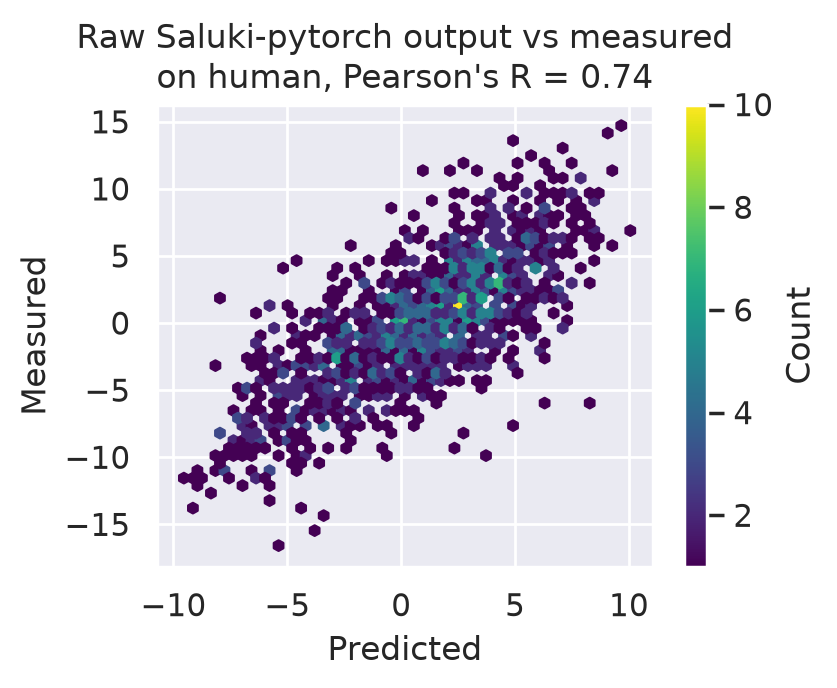

In [80]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    all_outputs,
    all_targets,
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki-pytorch output vs measured\non {species}, Pearson's R = {pearson(all_outputs, all_targets):.2f}")
plt.show()

In [56]:
df_toga = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv')

In [60]:
df_toga_val = df_toga[df_toga['fold'] == 1].copy()

In [63]:
df_toga_val['saluki_pytorch_pred'] = all_outputs

In [65]:
pearson(all_outputs, all_targets)

np.float32(0.7432)

In [66]:
pearson(df_toga_val['half_life'], df_toga_val['saluki_pytorch_pred'])

np.float64(0.7432)

In [55]:
df_val_genes = pd.read_csv("/s/project/ml4rg_students/2026/project03/project-half-life/results/val_genes.csv")

In [68]:
df_toga_val = df_toga_val.rename(columns={'gene': 'Gene'})

In [77]:
df_j = df_val_genes.set_index('Gene').join(
    df_toga_val.set_index('Gene')['saluki_pytorch_pred'], how='inner'
).reset_index()

In [78]:
df_j.shape

(1277, 8)

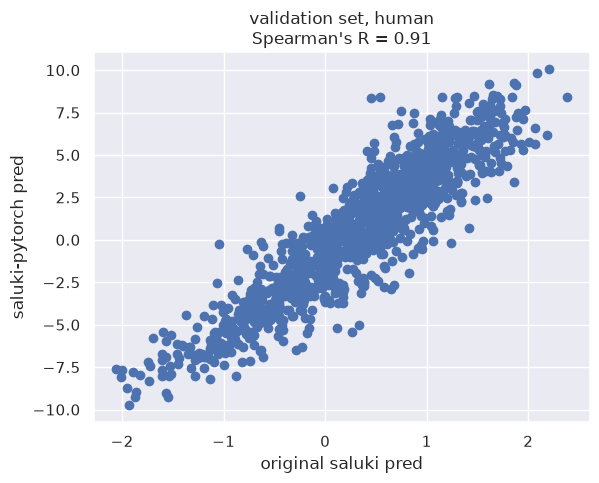

In [79]:
plt.scatter(df_j['orig_saluki_pred'], df_j['saluki_pytorch_pred'])
plt.xlabel('original saluki pred')
plt.ylabel('saluki-pytorch pred')
plt.title(f"validation set, human\nSpearman's R = {spearman(df_j['orig_saluki_pred'], df_j['saluki_pytorch_pred']):.2f}")
plt.show()